In [1]:
!pip install super-image tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.9/95.9 kB 2.8 MB/s eta 0:00:00


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
import os
import cv2
from torch.utils.data import Dataset
from torchvision import transforms

class SatelliteSRDataset(Dataset):
    def __init__(self, root_dir):
        self.lr_dir = os.path.join(root_dir, "LR")
        self.hr_dir = os.path.join(root_dir, "HR")
        self.filenames = sorted(os.listdir(self.lr_dir))
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]

        lr_path = os.path.join(self.lr_dir, filename)
        hr_path = os.path.join(self.hr_dir, filename)

        lr_img = cv2.imread(lr_path)
        hr_img = cv2.imread(hr_path)

        lr_img = cv2.cvtColor(lr_img, cv2.COLOR_BGR2RGB)
        hr_img = cv2.cvtColor(hr_img, cv2.COLOR_BGR2RGB)

        return self.to_tensor(lr_img), self.to_tensor(hr_img)


In [4]:
train_path = "/kaggle/input/datasets/sreekuwandoor/satellite-edsr-dataset/dataset/train"
val_path   = "/kaggle/input/datasets/sreekuwandoor/satellite-edsr-dataset/dataset/val"

train_dataset = SatelliteSRDataset(train_path)
val_dataset   = SatelliteSRDataset(val_path)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 1049
Val batches: 222


In [5]:
from super_image import EdsrModel

model = EdsrModel.from_pretrained('eugenesiow/edsr', scale=2).to(device)

criterion = torch.nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

print("Pretrained EDSR loaded.")


config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

pytorch_model_2x.pt:   0%|          | 0.00/163M [00:00<?, ?B/s]

https://huggingface.co/eugenesiow/edsr/resolve/main/pytorch_model_2x.pt
Pretrained EDSR loaded.


In [6]:
checkpoint_path = "/kaggle/working/edsr_checkpoint.pth"

start_epoch = 0

if os.path.exists(checkpoint_path):
    print("Checkpoint found. Resuming...")
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming from epoch {start_epoch}")
else:
    print("No checkpoint found. Starting fresh.")


No checkpoint found. Starting fresh.


In [7]:
from tqdm import tqdm

num_epochs = 5
max_train_batches = 300
max_val_batches = 100

for epoch in range(start_epoch, num_epochs):

    print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")

    # --------------------
    # TRAINING
    # --------------------
    model.train()
    train_loss = 0

    train_bar = tqdm(train_loader)

    for batch_idx, (lr, hr) in enumerate(train_bar):

        if batch_idx >= max_train_batches:
            break

        lr = lr.to(device)
        hr = hr.to(device)

        optimizer.zero_grad()
        sr = model(lr)
        loss = criterion(sr, hr)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / max_train_batches

    # Save checkpoint BEFORE validation
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict()
    }, checkpoint_path)

    print("Checkpoint saved.")

    # --------------------
    # VALIDATION
    # --------------------
    model.eval()
    val_loss = 0

    val_bar = tqdm(val_loader)

    with torch.no_grad():
        for batch_idx, (lr, hr) in enumerate(val_bar):

            if batch_idx >= max_val_batches:
                break

            lr = lr.to(device)
            hr = hr.to(device)

            sr = model(lr)
            loss = criterion(sr, hr)

            val_loss += loss.item()
            val_bar.set_postfix(val_loss=loss.item())

    avg_val_loss = val_loss / max_val_batches

    print(f"\nEpoch {epoch+1} Completed")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}")



===== Epoch 1/5 =====


 29%|██▊       | 300/1049 [14:34<36:22,  2.91s/it, loss=0.00968]


Checkpoint saved.


 45%|████▌     | 100/222 [02:06<02:34,  1.26s/it, val_loss=0.00951]



Epoch 1 Completed
Train Loss: 0.0094
Val Loss: 0.0095

===== Epoch 2/5 =====


...


Epoch 4 Completed
Train Loss: 0.0090
Val Loss: 0.0094

===== Epoch 5/5 =====


 29%|██▊       | 300/1049 [14:19<35:47,  2.87s/it, loss=0.00983]


Checkpoint saved.


 45%|████▌     | 100/222 [01:55<02:20,  1.15s/it, val_loss=0.00939]


Epoch 5 Completed
Train Loss: 0.0091
Val Loss: 0.0094


In [8]:
print(len(os.listdir("/kaggle/input/datasets/sreekuwandoor/satellite-edsr-dataset/dataset/train/LR")))
print(len(os.listdir("/kaggle/input/datasets/sreekuwandoor/satellite-edsr-dataset/dataset/test/LR")))
print(len(os.listdir("/kaggle/input/datasets/sreekuwandoor/satellite-edsr-dataset/dataset/val/LR")))


8386
1780
1771


In [9]:
# import os
# os.remove("/kaggle/working/edsr_checkpoint.pth")
# only fordeleting the savepoint

In [10]:
# code after running the traiining part

In [11]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from super_image import EdsrModel
from torch.utils.data import DataLoader
from skimage.metrics import structural_similarity as ssim
from torchvision.utils import save_image

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [13]:
model = EdsrModel.from_pretrained('eugenesiow/edsr', scale=2).to(device)

checkpoint_path = "/kaggle/working/edsr_checkpoint.pth"
checkpoint = torch.load(checkpoint_path)

model.load_state_dict(checkpoint['model_state'])
model.eval()

print("Model loaded successfully.")

https://huggingface.co/eugenesiow/edsr/resolve/main/pytorch_model_2x.pt
Model loaded successfully.


In [14]:
test_path = "/kaggle/input/datasets/sreekuwandoor/satellite-edsr-dataset/dataset/test"

test_dataset = SatelliteSRDataset(test_path)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print("Test samples:", len(test_dataset))

Test samples: 1780


In [15]:
def calculate_psnr(sr, hr):
    mse = torch.mean((sr - hr) ** 2)
    if mse == 0:
        return 100
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
    return psnr

In [16]:
def calculate_ssim(sr, hr):
    sr = sr.squeeze(0).permute(1,2,0).cpu().numpy()
    hr = hr.squeeze(0).permute(1,2,0).cpu().numpy()
    
    sr = np.clip(sr, 0, 1)
    hr = np.clip(hr, 0, 1)
    
    return ssim(sr, hr, channel_axis=2, data_range=1.0)

In [17]:
total_psnr = 0
total_ssim = 0
count = 0

with torch.no_grad():
    for lr, hr in tqdm(test_loader):

        lr = lr.to(device)
        hr = hr.to(device)

        sr = model(lr)

        psnr_value = calculate_psnr(sr, hr)
        ssim_value = calculate_ssim(sr, hr)

        total_psnr += psnr_value.item()
        total_ssim += ssim_value
        count += 1

avg_psnr = total_psnr / count
avg_ssim = total_ssim / count

print("\n===== FINAL TEST RESULTS =====")
print(f"Average Test PSNR: {avg_psnr:.2f} dB")
print(f"Average Test SSIM: {avg_ssim:.4f}")

100%|██████████| 1780/1780 [04:25<00:00,  6.71it/s]


===== FINAL TEST RESULTS =====
Average Test PSNR: 37.50 dB
Average Test SSIM: 0.9549


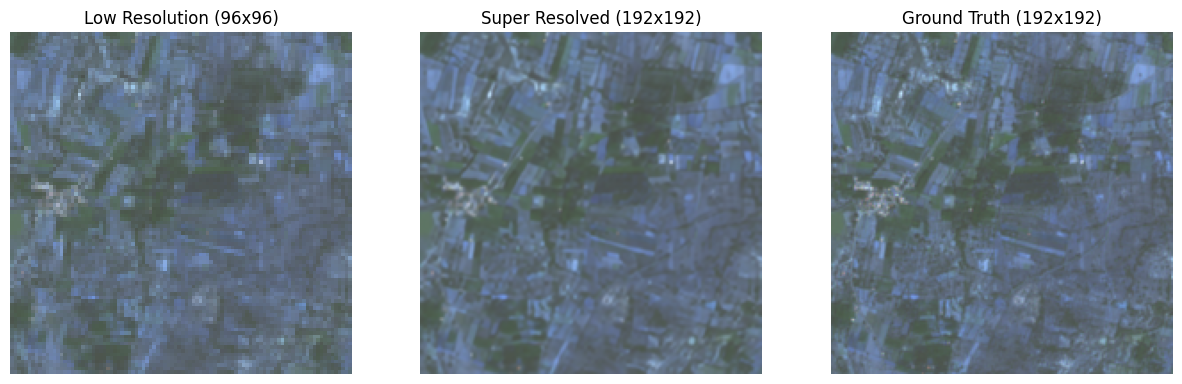

In [18]:
lr_sample, hr_sample = test_dataset[0]

lr_input = lr_sample.unsqueeze(0).to(device)

with torch.no_grad():
    sr_output = model(lr_input)

lr_img = lr_sample.permute(1,2,0).cpu().numpy()
sr_img = sr_output.squeeze(0).permute(1,2,0).cpu().numpy()
hr_img = hr_sample.permute(1,2,0).cpu().numpy()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Low Resolution (96x96)")
plt.imshow(lr_img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Super Resolved (192x192)")
plt.imshow(sr_img)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Ground Truth (192x192)")
plt.imshow(hr_img)
plt.axis("off")

plt.show()

In [19]:
os.makedirs("/kaggle/working/test_results", exist_ok=True)

with torch.no_grad():
    for i in range(5):

        lr, hr = test_dataset[i]
        lr_input = lr.unsqueeze(0).to(device)

        sr = model(lr_input)

        save_image(sr, f"/kaggle/working/test_results/sr_{i}.png")
        save_image(hr, f"/kaggle/working/test_results/hr_{i}.png")
        save_image(lr, f"/kaggle/working/test_results/lr_{i}.png")

print("Saved test results in /kaggle/working/test_results/")

Saved test results in /kaggle/working/test_results/
